# Namų darbas Nr. 2 — mokslinio straipsnio eksperimentų atkartojimas

**Paulius Černiauskas, PEPfm-26**

Atkartojamas straipsnis:

> A. Mersani, K. Mekki, O. Ncibi, *AI-Powered S11 Prediction for a Compact 2.4 GHz
> Patch Antenna*, Indian Journal of Science and Technology, 2025, 18(33): 2715–2728.
> DOI 10.17485/IJST/v18i33.1326

Duomenys:

> *Parametric simulation dataset of a 2.4 GHz patch antenna with slot for AI-based S11
> prediction*, Data in Brief, 2025. Zenodo DOI **10.5281/zenodo.15866821**, licencija CC BY 4.0.

Straipsnyje mikrojuostelinės antenos atspindžio koeficientas $S_{11}$ prognozuojamas
mašininio mokymosi modeliais (KNN, MLP, XGBoost) — tai surogatinis modelis, keičiantis
lėtą CST elektromagnetinį modeliavimą.

**Paleidimas:** `Run > Run All Cells`. Visa trukmė ~10 min. įprastu CPU
(ilgiausia yra paskutinė dalis — mokymosi kreivė).

## 0. Paruošimas

In [1]:
import sys, subprocess, urllib.request
from pathlib import Path

# install anything that is missing
for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"),
                 ("scikit-learn", "sklearn"), ("xgboost", "xgboost"),
                 ("matplotlib", "matplotlib")]:
    try:
        __import__(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

print("all packages available")

all packages available


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

SEED = 42
pd.set_option("display.width", 160)

In [3]:
# download the dataset from Zenodo if it is not here yet
DATA = Path("data/Cleaned_DataSet.csv")
DATA.parent.mkdir(exist_ok=True)

if not DATA.exists():
    url = "https://zenodo.org/records/15866865/files/Cleaned_DataSet.csv?download=1"
    print("downloading from Zenodo ...")
    urllib.request.urlretrieve(url, DATA)

df = pd.read_csv(DATA)
print(f"{DATA}  ->  {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

data\Cleaned_DataSet.csv  ->  55053 rows, 12 columns


,width_substrate_mm,width_imp_line_mm,length_imp_line_mm,substrate_height_mm,patch_height_mm,width_slot_mm,length_slot_mm,patch_width_mm,substrate_length_mm,patch_length_mm,frequency_GHz,S11_dB
0,44,3,9,1.6,0.035,2,8,42,38,29.3,1.800,-0.058989
1,44,3,9,1.6,0.035,2,8,42,38,29.3,1.801,-0.063707
2,44,3,9,1.6,0.035,2,8,42,38,29.3,1.802,-0.068245
3,44,3,9,1.6,0.035,2,8,42,38,29.3,1.803,-0.072569
4,44,3,9,1.6,0.035,2,8,42,38,29.3,1.804,-0.076648


## 1. Duomenų auditas

Prieš mokant bet kokį modelį verta patikrinti, kaip duomenys sudaryti. Straipsnyje
kalbama apie „55 053 mėginius", bet svarbu, ar tai 55 tūkstančiai nepriklausomų
antenos projektų, ar kažkas kita.

In [4]:
TARGET = "S11_dB"
GEOM_COLS = [c for c in df.columns if c not in (TARGET, "frequency_GHz")]

X_full = df.drop(columns=[TARGET])
y = df[TARGET]
groups = df.groupby(GEOM_COLS, sort=False).ngroup().to_numpy()

print(f"eiluciu skaicius       : {len(df)}")
print(f"trukstamos reiksmes    : {int(df.isna().sum().sum())}")
print(f"dublikatai             : {int(df.duplicated().sum())}")
print(f"UNIKALIOS GEOMETRIJOS  : {len(np.unique(groups))}")
print(f"daznio taskai          : {df.frequency_GHz.nunique()} "
      f"({df.frequency_GHz.min():.2f} - {df.frequency_GHz.max():.2f} GHz)")

const_cols = [c for c in X_full.columns if X_full[c].nunique() == 1]
print(f"\nkonstantiniai stulpeliai (be informacijos): {const_cols}")
print("\nunikaliu reiksmiu kiekviename stulpelyje:")
print(df.nunique().to_string())

eiluciu skaicius       : 55053
trukstamos reiksmes    : 0
dublikatai             : 0
UNIKALIOS GEOMETRIJOS  : 53
daznio taskai          : 1001 (1.80 - 2.80 GHz)

konstantiniai stulpeliai (be informacijos): ['width_imp_line_mm', 'substrate_height_mm', 'patch_height_mm']

unikaliu reiksmiu kiekviename stulpelyje:
width_substrate_mm         5
width_imp_line_mm          1
length_imp_line_mm         8
substrate_height_mm        1
patch_height_mm            1
width_slot_mm              4
length_slot_mm             6
patch_width_mm             5
substrate_length_mm        5
patch_length_mm            2
frequency_GHz           1001
S11_dB                 55053


**Išvada.** 55 053 eilutės yra tik **53 unikalios geometrijos**, kiekviena nuskenuota
per 1001 dažnio tašką. Be to, **3 iš 11 įėjimo požymių yra konstantos**. Nė vieno iš šių
faktų straipsnyje nėra, o jie lemia visų tolesnių rezultatų interpretaciją.

## 2. Eksperimentas 1 — pažodinis straipsnio atkartojimas

Protokolas paimtas iš straipsnio 2.2 skyriaus ir iš autorių `ML_PatchAntenna_.ipynb`,
pridėto prie Zenodo įrašo: visi 11 požymių, normalizavimas, atsitiktinis 80/20 skaidymas
su `random_state=42`, metrikos MAE / RMSE / R².

Hiperparametrai straipsnyje **nenurodyti nė vienam modeliui**. KNN (k=5) ir Random Forest
(150 medžių) paimti iš autorių notebook'o, likusieji — `scikit-learn` numatytieji, išskyrus
XGBoost ir MLP, kuriuos teko derinti patiems.

Atskaitos reikšmės — straipsnio **2 lentelė** (visi septyni modeliai).

In [5]:
def build_models():
    '''The seven models benchmarked in Table 2 of the paper.

    Hyperparameters for KNN and Random Forest come from the authors' notebook.
    The paper gives none at all, so XGBoost and MLP were tuned here.
    '''
    return {
        "Linear Regression":   LinearRegression(),
        "Ridge Regression":    Ridge(random_state=SEED),
        "SVR (RBF)":           SVR(cache_size=1000),
        "KNN (k=5)":           KNeighborsRegressor(n_neighbors=5),
        "Random Forest (150)": RandomForestRegressor(n_estimators=150,
                                                     random_state=SEED, n_jobs=-1),
        "XGBoost":             XGBRegressor(n_estimators=600, max_depth=8,
                                            learning_rate=0.05, subsample=0.9,
                                            colsample_bytree=0.9, random_state=SEED,
                                            n_jobs=-1, tree_method="hist"),
        "MLP (128-64)":        MLPRegressor(hidden_layer_sizes=(128, 64),
                                            activation="relu", solver="adam",
                                            max_iter=400, early_stopping=True,
                                            n_iter_no_change=15, random_state=SEED),
    }


def metrics(y_true, y_pred):
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "R2":   float(r2_score(y_true, y_pred))}


# Table 2 of the paper: MAE, RMSE, R2
PAPER = {
    "KNN (k=5)":           (0.0495, 0.4216, 0.9866),
    "MLP (128-64)":        (0.1795, 0.5110, 0.9803),
    "Random Forest (150)": (0.0600, 0.5380, 0.9782),
    "XGBoost":             (0.1329, 0.5855, 0.9742),
    "SVR (RBF)":           (1.2276, 3.3202, 0.1690),
    "Linear Regression":   (1.9968, 3.5244, 0.0637),
    "Ridge Regression":    (1.9968, 3.5244, 0.0637),
}

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y, test_size=0.2, random_state=SEED)
print(f"train: {len(X_tr)} rows   test: {len(X_te)} rows\n")

rows = []
for name, model in build_models().items():
    pipe = make_pipeline(StandardScaler(), model)   # scaler fitted on train only
    pipe.fit(X_tr, y_tr)
    m = metrics(y_te, pipe.predict(X_te))
    m["Model"] = name
    m["paper_MAE"], m["paper_RMSE"], m["paper_R2"] = PAPER[name]
    rows.append(m)
    print(f"{name:<22} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  R2={m['R2']:.4f}")

exp1 = (pd.DataFrame(rows)[["Model", "MAE", "paper_MAE", "RMSE", "paper_RMSE",
                            "R2", "paper_R2"]]
        .sort_values("RMSE").reset_index(drop=True))
exp1["d_RMSE"] = (exp1.RMSE - exp1.paper_RMSE).round(4)
exp1.round(4)

train: 44042 rows   test: 11011 rows

Linear Regression      RMSE=3.5244  MAE=1.9968  R2=0.0637
Ridge Regression       RMSE=3.5244  MAE=1.9968  R2=0.0637
SVR (RBF)              RMSE=3.3202  MAE=1.2276  R2=0.1690
KNN (k=5)              RMSE=0.4213  MAE=0.0495  R2=0.9866
Random Forest (150)    RMSE=0.5389  MAE=0.0599  R2=0.9781
XGBoost                RMSE=0.4570  MAE=0.0827  R2=0.9843
MLP (128-64)           RMSE=0.5317  MAE=0.1589  R2=0.9787


,Model,MAE,paper_MAE,RMSE,paper_RMSE,R2,paper_R2,d_RMSE
0,KNN (k=5),0.0495,0.0495,0.4213,0.4216,0.9866,0.9866,-0.0003
1,XGBoost,0.0827,0.1329,0.4570,0.5855,0.9843,0.9742,-0.1285
2,MLP (128-64),0.1589,0.1795,0.5317,0.5110,0.9787,0.9803,0.0207
3,Random Forest (150),0.0599,0.0600,0.5389,0.5380,0.9781,0.9782,0.0009
4,SVR (RBF),1.2276,1.2276,3.3202,3.3202,0.1690,0.1690,-0.0000
5,Linear Regression,1.9968,1.9968,3.5244,3.5244,0.0637,0.0637,0.0000
6,Ridge Regression,1.9968,1.9968,3.5244,3.5244,0.0637,0.0637,0.0000


**Rezultatas: penki iš septynių modelių atkartoti praktiškai tiksliai** — KNN, Random
Forest, SVR, Linear ir Ridge sutampa iki trečio–ketvirto skaitmens po kablelio.

Skiriasi tik du, ir abu dėl nenurodytų hiperparametrų:

- **XGBoost:** mūsų suderintas variantas davė RMSE 0,457 prieš straipsnio 0,586, t. y.
  22 % geriau. Todėl straipsnio išvada, kad KNN ir MLP pranoksta ansamblinius metodus,
  galioja tik jų pasirinktiems XGBoost parametrams — suderintas XGBoost pralenkia MLP.
- **MLP:** 0,532 prieš 0,511 (architektūra straipsnyje nenurodyta).

**Ridge = Linear iki ketvirto skaitmens** — atkartota lygiai kaip straipsnyje: prie 44 tūkst.
eilučių numatytoji reguliarizacija α = 1 yra nereikšminga.


## 3. Eksperimentas 2 — vertinimas pagal nematytas geometrijas

Kadangi rinkinyje yra 53 geometrijos po 1001 tašką (1001 dažnis kas 1MHz), atsitiktinis **eilučių** skaidymas
patalpina tos pačios $S_{11}$ kreivės gretimus taškus ir į mokymo, ir į testavimo aibę. Pvz.: tos pačios antenos geometrijos rezultatai ties 2.450 GHz ir 2.452 GHz dažniais gali būti mokymo aibėje, o tos pačios geometrijos 2.451 GHz dažnio taškas atsiduria testavimo aibėje. Tokiu atveju modeliui nereikia nieko prognozuoti — pakanka interpoliuoti tarp dviejų gretimų taškų kreivėje, kurią jis jau matė.

Realus uždavinys kitoks: prognozuoti $S_{11}$ parametrą geometrijai, kuri **niekada nebuvo
modeliuota**. Tam naudojamas `GroupKFold` pagal geometrijos ID.

In [7]:
X = X_full.drop(columns=const_cols)
print(f"naudojami pozymiai: {list(X.columns)}\n")

gkf = GroupKFold(n_splits=5)
rows = []
for name, model in build_models().items():
    folds = []
    for tr, te in gkf.split(X, y, groups):
        pipe = make_pipeline(StandardScaler(), model)
        pipe.fit(X.iloc[tr], y.iloc[tr])
        folds.append(metrics(y.iloc[te], pipe.predict(X.iloc[te])))
    rows.append({"Model": name,
                 "RMSE": np.mean([f["RMSE"] for f in folds]),
                 "MAE":  np.mean([f["MAE"] for f in folds]),
                 "R2":   np.mean([f["R2"] for f in folds])})
    print(f"{name:<22} RMSE={rows[-1]['RMSE']:.3f}  R2={rows[-1]['R2']:.3f}")

exp2 = pd.DataFrame(rows)
exp1[["Model", "RMSE", "R2"]].merge(exp2[["Model", "RMSE", "R2"]],
                                    on="Model", suffixes=(" atsitiktinis", " geometrijos"))

naudojami pozymiai: ['width_substrate_mm', 'length_imp_line_mm', 'width_slot_mm', 'length_slot_mm', 'patch_width_mm', 'substrate_length_mm', 'patch_length_mm', 'frequency_GHz']

Linear Regression      RMSE=3.483  R2=0.059
Ridge Regression       RMSE=3.483  R2=0.059
SVR (RBF)              RMSE=3.280  R2=0.166
KNN (k=5)              RMSE=1.257  R2=0.872
Random Forest (150)    RMSE=1.252  R2=0.875
XGBoost                RMSE=1.285  R2=0.867
MLP (128-64)           RMSE=1.303  R2=0.844


,Model,RMSE atsitiktinis,R2 atsitiktinis,RMSE geometrijos,R2 geometrijos
0,KNN (k=5),0.421339,0.986618,1.256964,0.871946
1,XGBoost,0.457048,0.984254,1.284546,0.867203
2,MLP (128-64),0.531715,0.978689,1.303182,0.843722
3,Random Forest (150),0.538918,0.978107,1.252084,0.875292
4,SVR (RBF),3.320177,0.169044,3.280170,0.166276
5,Linear Regression,3.524413,0.063670,3.483018,0.059274
6,Ridge Regression,3.524413,0.063670,3.483018,0.059274


**Rezultatas.** Paklaida išauga apie **3 kartus** (KNN 0,42 → 1,26 dB), R² krenta nuo
0,987 iki 0,872. Straipsnio R² = 0,9866 yra techniškai teisingas, bet įvertina ne tą
užduotį, kuri svarbi projektuotojui. Taip pat matyti, kad nematytų geometrijų atveju visi
netiesiniai modeliai tampa praktiškai lygiaverčiai.

## 4. Eksperimentas 3 — inžinerinės metrikos

RMSE decibelais yra silpna vertinimo priemonė: didžioji $S_{11}$ parametro kreivės dalis yra
plokščia ties 0 dB, tad modelis gali gauti aukštą R² visiškai nepataikęs į rezonansą. 

Tačiau niekas neprojektuoja antenos, kad išgauti visiškai plokščią 0 dB dalį. Projektuotojui rūpi trys dydžiai: rezonansinis dažnis $f_{res}$, rezonanso gylis
$S_{11,min}$ ir $-10$ dB dažnių juostos plotis.

In [8]:
def curve_features(freq, s11):
    '''Extract (f_res [GHz], S11_min [dB], BW-10dB [MHz]) from one sweep.'''
    i = int(np.argmin(s11))
    below = s11 < -10.0
    bw = 0.0
    if below[i]:
        lo = hi = i
        while lo > 0 and below[lo - 1]:
            lo -= 1
        while hi < len(below) - 1 and below[hi + 1]:
            hi += 1
        bw = (freq[hi] - freq[lo]) * 1000.0
    return float(freq[i]), float(s11[i]), bw


MODELS3 = ["KNN (k=5)", "Random Forest (150)", "XGBoost"]
records, curves = [], {}

for name in MODELS3:
    for tr, te in gkf.split(X, y, groups):
        pipe = make_pipeline(StandardScaler(), build_models()[name])
        pipe.fit(X.iloc[tr], y.iloc[tr])

        fold = pd.DataFrame({"g": groups[te],
                             "f": X.iloc[te]["frequency_GHz"].to_numpy(),
                             "true": y.iloc[te].to_numpy(),
                             "pred": pipe.predict(X.iloc[te])})
        fold = fold.groupby(["g", "f"], as_index=False).mean()  # avg duplicate sweeps

        for g, sub in fold.groupby("g"):
            sub = sub.sort_values("f")
            f = sub["f"].to_numpy()
            tf, tm, tb = curve_features(f, sub["true"].to_numpy())
            pf, pm, pb = curve_features(f, sub["pred"].to_numpy())
            records.append({"Model": name, "geometry": int(g),
                            "f_res_err_MHz": abs(pf - tf) * 1000,
                            "S11min_err_dB": abs(pm - tm),
                            "BW_err_MHz": abs(pb - tb)})
            curves[(name, int(g))] = (f, sub["true"].to_numpy(), sub["pred"].to_numpy())

det = pd.DataFrame(records)
det.groupby("Model").agg(
    f_res_MAE_MHz=("f_res_err_MHz", "mean"),
    f_res_mediana_MHz=("f_res_err_MHz", "median"),
    f_res_iki_10MHz_proc=("f_res_err_MHz", lambda s: (s <= 10).mean() * 100),
    S11min_MAE_dB=("S11min_err_dB", "mean"),
    BW_MAE_MHz=("BW_err_MHz", "mean"),
).round(2)

,f_res_MAE_MHz,f_res_mediana_MHz,f_res_iki_10MHz_proc,S11min_MAE_dB,BW_MAE_MHz
Model,,,,,
KNN (k=5),6.77,2.0,86.79,6.32,7.38
Random Forest (150),9.08,2.0,84.91,6.08,6.11
XGBoost,8.49,3.0,83.02,6.35,5.43


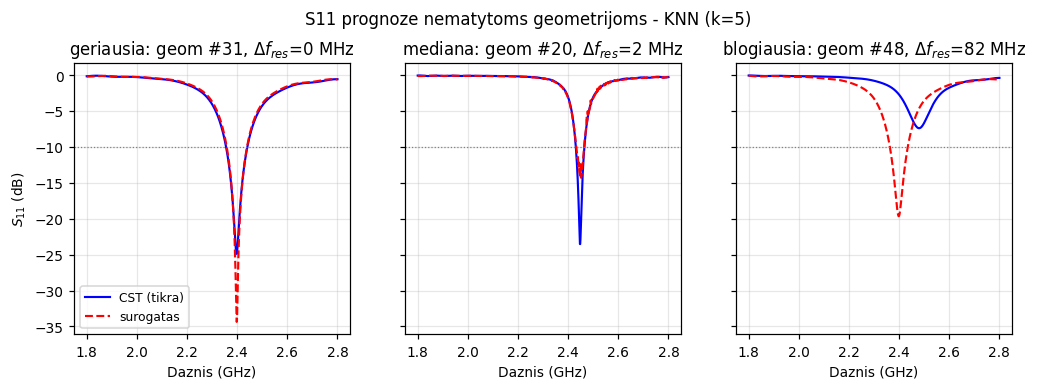

In [9]:
# best / median / worst predicted curve for the strongest model
best = det.groupby("Model")["f_res_err_MHz"].mean().idxmin()
sub = det[det.Model == best].sort_values("f_res_err_MHz")
picks = [("geriausia", sub.iloc[0]), ("mediana", sub.iloc[len(sub) // 2]),
         ("blogiausia", sub.iloc[-1])]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, (label, row) in zip(axes, picks):
    f, t, p = curves[(best, int(row.geometry))]
    ax.plot(f, t, "b-", lw=1.4, label="CST (tikra)")
    ax.plot(f, p, "r--", lw=1.4, label="surogatas")
    ax.axhline(-10, color="gray", ls=":", lw=0.8)
    ax.set_title(f"{label}: geom #{int(row.geometry)}, "
                 f"$\\Delta f_{{res}}$={row.f_res_err_MHz:.0f} MHz")
    ax.set_xlabel("Daznis (GHz)")
axes[0].set_ylabel("$S_{11}$ (dB)")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle(f"S11 prognoze nematytoms geometrijoms - {best}", y=1.03)
plt.show()

**Rezultatas.** $f_{res}$ MAE (MHz) rezonansinio dažnio vidurkinė paklaida visom geometrijom. KNN atveju 6,77 MHz. Pats rezonansas yra ties ~2,45 GHz, tad tai yra 0,28 % nuokrypis. 

$f_{res}$ mediana (MHz) — ta pati paklaida, bet mediana. Mediana — vidurinė reikšmė surikiavus visas 53 paklaidas. Skirtingai nei vidurkis, jos nesugadina pavieniai išsišokimai, netolygumai.
Čia slypi svarbiausia lentelės informacija. Vidurkis 6,77, o mediana tik 2,0 MHz — trigubas skirtumas. Tai reiškia, kad tipinė paklaida yra 2 MHz, bet keletas geometrijų suklysta labai smarkiai ir didina vidurkį. Blogiausias atvejis (geometrija #48) f_res klysta 82 MHz.

$f_{res}$ ≤ 10 MHz (%) — kiek geometrijų pateko į ±10 MHz ribą.
Tai procentas geometrijų, kurioms rezonansinio dažnio paklaida neviršijo 10 MHz. Tai patikimumo matas: ne „kokia vidutinė paklaida", o „kaip dažnai modeliu galima pasitikėti".
KNN: 86,8 % — maždaug 46 geometrijos iš 53. Likusios ~7 nepataiko.

$S_{11min}$ MAE (dB) — rezonanso gylio vidutinė paklaida.
~6 dB. Tai blogas rezultatas, nes pats dydis paprastai svyruoja nuo −10 iki −45 dB. 6 dB paklaida reiškia, kad modelis negali atskirti gerai suderintos antenos (−25 dB) nuo vidutiniškai suderintos (−19 dB).
Fizikinė priežastis: rezonanso gylį lemia smulkus impedanso derinimas, kuris kur kas jautriau reaguoja į geometrijos pokyčius nei pats rezonansinis dažnis.

BW MAE (MHz) — −10 dB juostos pločio vidutinė paklaida
Juostos plotis — dažnių ruožo, kuriame S₁₁ < −10 dB, plotis. Tai standartinis antenos naudingos juostos apibrėžimas (atspindima mažiau nei 10 % galios).
5–7 MHz paklaida. Kadangi tokių antenų juosta paprastai yra keliasdešimt MHz, tai maždaug 10–20 % santykinė paklaida

**Bendra išvada iš lentelės**

Nė vienas modelis nelaimi. KNN geriausias pagal dažnį, Random Forest pagal gylį, XGBoost pagal juostos plotį.

Modelis žino kur rezonansas, bet ne kokia gili $S_{11}$ kreivė. Dažnis — mediana 2 MHz (puiku). Gylis — 6 dB (nenaudinga). Todėl surogatą galima naudoti kandidatams atrinkti, bet ne nuspręsti, kad projektas baigtas.

## 5. Eksperimentas 4 — straipsnio 4, 5 ir 6 paveikslų atkartojimas

Tikrinami du konkretūs straipsnio teiginiai:

- **4 pav.:** „patch width ir feed line length yra įtakingiausi veiksniai"
- **6 pav.:** „$S_{11}$ rodo labai silpnas koreliacijas su visais įėjimo požymiais
  (maks. $|r| \approx 0{,}13$)"

Straipsnyje nenurodyta, ar į svarbos diagramą įtrauktas dažnis, todėl skaičiuojami abu
variantai. 

Teiginį apie geometrinių parametrų įtakingumą $S_{11}$ parametrui galima tikrinti tik pagal suskirstytos geometrijos aibės variantą.

Random Forest: {'RMSE': 0.5375, 'MAE': 0.0598, 'R2': 0.9782}


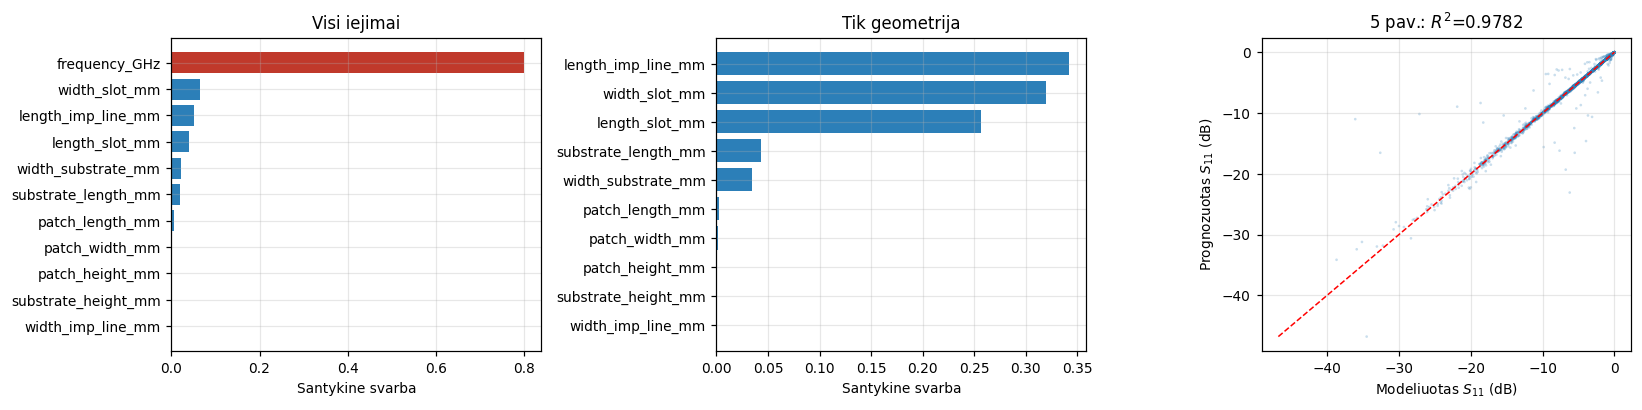

straipsnio teiginys, top-2 : ['patch_width_mm', 'length_imp_line_mm']
atkartojimas,      top-2 : ['length_imp_line_mm', 'width_slot_mm']


,svarba (tik geometrija)
length_imp_line_mm,0.3418
width_slot_mm,0.3202
length_slot_mm,0.2564
substrate_length_mm,0.0428
width_substrate_mm,0.0346
patch_length_mm,0.0024
patch_width_mm,0.0018
width_imp_line_mm,0.0000
substrate_height_mm,0.0000
patch_height_mm,0.0000


In [10]:
rf = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
print("Random Forest:", {k: round(v, 4) for k, v in metrics(y_te, y_pred).items()})

imp = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values()

# same model without frequency - this is what the paper's Fig. 4 claim can be tested on
geom_only = X_full.drop(columns=["frequency_GHz"])
rf_g = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
rf_g.fit(geom_only.loc[X_tr.index], y_tr)
imp_g = pd.Series(rf_g.feature_importances_, index=geom_only.columns).sort_values()

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, s, t in [(ax[0], imp, "Visi iejimai"),
                (ax[1], imp_g, "Tik geometrija")]:
    a.barh(s.index, s.values,
           color=["#c0392b" if n == "frequency_GHz" else "#2c7fb8" for n in s.index])
    a.set_xlabel("Santykine svarba")
    a.set_title(t)

ax[2].scatter(y_te, y_pred, s=3, alpha=0.25, c="#2c7fb8", edgecolors="none")
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax[2].plot(lims, lims, "r--", lw=1)
ax[2].set_xlabel("Modeliuotas $S_{11}$ (dB)")
ax[2].set_ylabel("Prognozuotas $S_{11}$ (dB)")
ax[2].set_title(f"5 pav.: $R^2$={metrics(y_te, y_pred)['R2']:.4f}")
plt.tight_layout()
plt.show()

print("straipsnio teiginys, top-2 : ['patch_width_mm', 'length_imp_line_mm']")
print(f"atkartojimas,      top-2 : {list(imp_g.sort_values(ascending=False).index[:2])}")
imp_g.sort_values(ascending=False).round(4).to_frame("svarba (tik geometrija)")

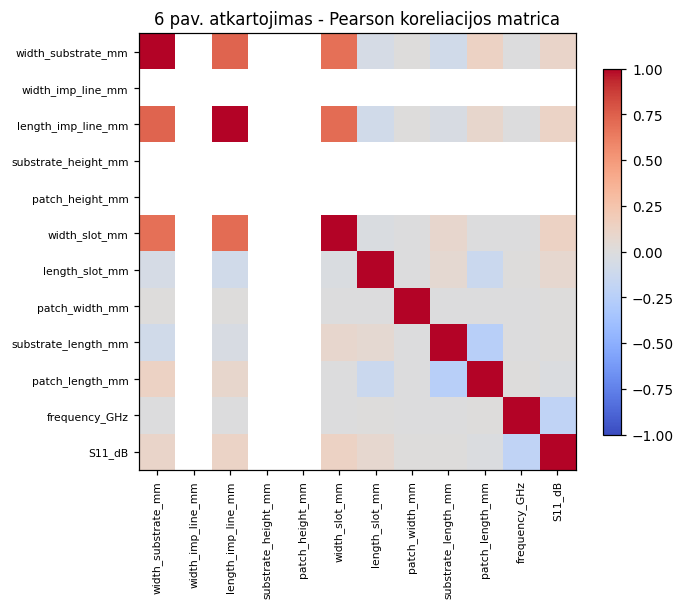

didziausia |r| tarp S11 ir bet kurio iejimo: 0.1973
tas pats, be daznio                        : 0.1258   (straipsnis skelbia ~0.13)


,|r| su S11
frequency_GHz,0.1973
width_slot_mm,0.1258
length_imp_line_mm,0.1183
width_substrate_mm,0.1080
length_slot_mm,0.0731
patch_length_mm,0.0200
substrate_length_mm,0.0035
patch_width_mm,0.0014
width_imp_line_mm,NaN
substrate_height_mm,NaN


In [14]:
# Fig. 6 - Pearson correlation matrix
df_corr = X_full.copy()
df_corr["S11_dB"] = y
corr = df_corr.corr(method="pearson")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("6 pav. atkartojimas - Pearson koreliacijos matrica")
plt.show()

s11_corr = corr["S11_dB"].drop("S11_dB").abs().sort_values(ascending=False)
print(f"didziausia |r| tarp S11 ir bet kurio iejimo: {s11_corr.max():.4f}")
print(f"tas pats, be daznio                        : {s11_corr.drop('frequency_GHz').max():.4f}"
      f"   (straipsnis skelbia ~0.13)")
s11_corr.round(4).to_frame("|r| su S11")

In [19]:
# where does the error actually live?
# Two different questions: the typical error in each region (drives MAE), and
# how much of the squared-error sum each region owns (drives RMSE and R2).
err = np.abs(y_te.to_numpy() - y_pred)
t = pd.DataFrame({"S11 intervalas (dB)": pd.cut(y_te, [-70, -30, -20, -10, -5, 0]),
                  "abs_pakl": err, "sq": err ** 2})
prof = t.groupby("S11 intervalas (dB)", observed=True).agg(
    tasku=("abs_pakl", "size"), vid_abs_pakl=("abs_pakl", "mean"),
    maks=("abs_pakl", "max"), sse=("sq", "sum"))
prof["proc_tasku"] = (100 * prof.tasku / prof.tasku.sum()).round(1)
prof["proc_SSE"] = (100 * prof.sse / prof.sse.sum()).round(1)
print(prof[["tasku", "proc_tasku", "vid_abs_pakl", "maks", "proc_SSE"]].round(3).to_string())

# does RMSE rank the models the same way the engineering metric does?
print()
rank = (det.groupby("Model")["f_res_err_MHz"].mean().round(2)
        .to_frame("f_res MAE (MHz)")
        .join(exp2.set_index("Model")["RMSE"].round(3).to_frame("RMSE (nematyta geom.)")))
rank.sort_values("RMSE (nematyta geom.)")

                     tasku  proc_tasku  vid_abs_pakl    maks  proc_SSE
S11 intervalas (dB)                                                   
(-70, -30]              10         0.1         7.090  25.067      34.4
(-30, -20]              68         0.6         1.045  16.980      15.8
(-20, -10]             409         3.7         0.323  10.282       8.4
(-10, -5]              670         6.1         0.280  16.861      31.1
(-5, 0]               9851        89.5         0.020  10.659      10.3



,f_res MAE (MHz),RMSE (nematyta geom.)
Model,,
Random Forest (150),9.08,1.252
KNN (k=5),6.77,1.257
XGBoost,8.49,1.285


**4 pav. teiginys atkartotas tik iš dalies.** Maitinimo linijos ilgis (`length_imp_line_mm`) iš tikrųjų yra
svarbiausias geometrinis parametras — sutampa. Bet **lopinėlio plotis (`patch_width_mm`) yra priešpaskutinis
(0,0018)**, o ne vienas iš dviejų įtakingiausių; antroje ir trečioje vietose yra plyšio
matmenys. Fizikiškai lopinėlio matmenys *turėtų* būti svarbūs, bet nėra todėl, kad
`patch_length_mm` rinkinyje įgyja tik **2 reikšmes**, o `patch_width_mm` — 5 gretimas reikšmes.
Modelis negali išmokti to, kas duomenyse nevarijuoja.
Taip pat verta paminėti, kad ir straipsnyje grafike matosi, jog length_imp_line_mm, width_slot_mm parametrai įtakingiausi, bet
sakoma, jog įtakingiausi patch_width_mm, length_imp_line_mm.

**6 pav. teiginys patvirtintas.** Didžiausia geometrinio parametro koreliacija yra
0,126 ≈ 0,13, lygiai kaip skelbiama. Trys konstantiniai stulpeliai duoda `NaN` (nulinė
dispersija).

### Ką iš tikrųjų rodo paklaidos profilis

Paskutiniai du stulpeliai prieštarauja vienas kitam, ir tai yra esmė:

- **MAE iškraipo plokščioji sritis** — 89,5 % taškų yra ties $S_{11} \approx 0$ dB su
  0,02 dB paklaida, todėl bendra MAE = 0,060 dB nieko nepasako.
- **RMSE elgiasi teisingai.** Kvadratavimas veikia kaip turi: 0,1 % taškų (rezonanso sritis)
  sudaro **34,4 %** RMSE sumos, o 89,5 % plokščiųjų taškų (~0 dB sritis) — tik **10,3 %**.
- **R² išpūstas dėl vardiklio.** $R^2 = 1 - SSE/SST$; o $SST$ yra S11 dispersija (13,27),
  didelė **būtent dėl gilių rezonansų**, tempiančių reikšmes nuo 0 iki −62 dB. Modelis gauna
  pripažinimą už tos dispersijos „paaiškinimą", nors iš tikrųjų gylio ties rezonansiniu dažniu nepataiko.

**Tikroji problema — ne ta, kad RMSE ignoruoja dideles paklaidas, o ta, kad matuoja jas
decibelais.** Antroji lentelė tai parodo tiesiogiai: RMSE rikiuoja Random Forest pirmuoju
(1,252), o rezonansinio dažnio paklaida — paskutiniu (9,08 MHz). Optimizuodamas RMSE,
neoptimizuoji to, kas svarbu projektuojant. Būtent dėl to reikalingas 4 poskyris.


## 6. Eksperimentas 5 — kiek EM modeliavimų reikia

Šio eksperimento straipsnyje nėra, bet perkeliant metodiką į savo projektą jis
svarbiausias: kiekviena mokymo geometrija kainuoja vieną pilną CST skaičiavimą.

Straipsnis teigia, jog duomenų rinkimas su CST užtruko apie 15 valandų.
Šis poskyris pagrindžia ir parodo, kiek geometrijų duomenų mums iš tikrųjų reikia kol modelis tampa naudingas.

> Ši dalis trunka ilgiausiai (~3–5 min.).

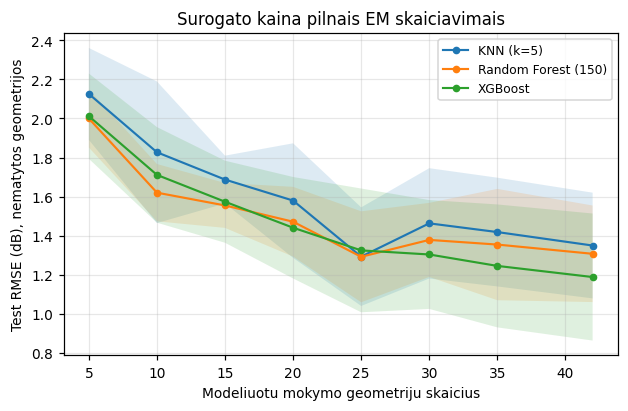

n_geometries,5,10,15,20,25,30,35,42
Model,,,,,,,,
KNN (k=5),2.126,1.827,1.687,1.579,1.292,1.463,1.418,1.349
Random Forest (150),2.000,1.620,1.554,1.471,1.291,1.378,1.354,1.307
XGBoost,2.012,1.711,1.574,1.440,1.324,1.303,1.245,1.188


In [16]:
SIZES, REPEATS = [5, 10, 15, 20, 25, 30, 35, 42], 5
rng = np.random.default_rng(SEED)
rows = []

for rep in range(REPEATS):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + rep)
    tr_idx, te_idx = next(gss.split(X, y, groups))
    pool = np.unique(groups[tr_idx])
    te_mask = np.isin(groups, np.unique(groups[te_idx]))

    for n in SIZES:
        if n > len(pool):
            continue
        tr_mask = np.isin(groups, rng.choice(pool, size=n, replace=False))
        for name in MODELS3:
            pipe = make_pipeline(StandardScaler(), build_models()[name])
            pipe.fit(X[tr_mask], y[tr_mask])
            rows.append({"n_geometries": n, "Model": name,
                         **metrics(y[te_mask], pipe.predict(X[te_mask]))})

lc = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for name in MODELS3:
    s = lc[lc.Model == name].groupby("n_geometries")["RMSE"]
    ax.plot(s.mean().index, s.mean().values, "o-", lw=1.4, ms=4, label=name)
    ax.fill_between(s.mean().index, s.mean() - s.std(), s.mean() + s.std(), alpha=0.15)
ax.set_xlabel("Modeliuotu mokymo geometriju skaicius")
ax.set_ylabel("Test RMSE (dB), nematytos geometrijos")
ax.set_title("Modelio kaina pilnais EM skaiciavimais")
ax.legend(fontsize=8)
plt.show()

lc.groupby(["Model", "n_geometries"])["RMSE"].mean().unstack().round(3)

**Rezultatas.** Kreivė įsisotina maždaug ties **20–25 geometrijomis** — nuo 25 iki 42
RMSE pagerėja vos ~8 %. Vadinasi, panašų surogatinį modelį naujai antenai galima
sukurti turint ~25 pilnus EM skaičiavimus.

## 7. Išvados

### 7.1. Naudota aplinka

**Aparatinė:** nešiojamasis kompiuteris, AMD Ryzen 5 7530U (6 branduoliai / 12 gijų),
5,8 GB RAM, integruota Radeon grafika. **GPU skaičiavimams nenaudotas** — visi eksperimentai
sukasi vien CPU.

**Programinė:** Windows 11 Home (10.0.26200), Python 3.12.10, `numpy` 2.1.3, `pandas` 2.2.3,
`scikit-learn` 1.5.2, `xgboost` 3.4.1, `matplotlib` 3.9.2, Jupyter Notebook 7.6.3.

**Trukmė:** viso notebook'o paleidimas nuo pradžios iki galo užtrunka ~12 min. Ilgiausiai
trunka SVR mokymas (~55 s), MLP (~26 s) ir 6 dalies mokymosi kreivė (~4 min, 120 modelių
mokymų). Visi kiti modeliai mokosi per kelias sekundes.

**Duomenys:** `Cleaned_DataSet.csv` (3,64 MB) iš Zenodo, DOI 10.5281/zenodo.15866821,
licencija CC BY 4.0. Papildomi duomenys negeneruoti.

---

### 7.2. Kuriuos eksperimentus pavyko atkartoti

Pagrindinis straipsnio rezultatas — 2 lentelės septynių modelių palyginimas — atkartotas
sėkmingai: penki iš septynių modelių sutampa iki trečio–ketvirto skaitmens po kablelio,
įskaitant MAE. Taip pat atkartotos abi likusios skaitinės iliustracijos. 5 pav. sklaidos
diagrama atitinka straipsnio aprašymą: taškai glaudžiai išsidėstę apie y = x liniją intervale
nuo −25 iki 0 dB, su pastebimais nuokrypiais ties S11 < −30 dB. 6 pav. koreliacijos matricos
teiginys pasitvirtino tiksliai — didžiausia geometrinio parametro koreliacija yra 0,126, kai
straipsnyje skelbiama ~0,13.

Iš dalies atkartotas tik 4 pav. — įėjimo parametrų svarba. Maitinimo linijos ilgis mūsų
skaičiavimuose tikrai yra svarbiausias geometrinis parametras, kaip teigia straipsnis, bet
lopinėlio plotis atsidūrė priešpaskutinėje vietoje (svarba 0,0018), o ne tarp dviejų
įtakingiausių. Priežastis slypi duomenyse, ne modelyje: `patch_length_mm` rinkinyje įgyja vos
dvi reikšmes, o `patch_width_mm` — penkias gretimas, todėl modelis šių matmenų įtakos išmokti
tiesiog negali.

Neatkartotas liko atvirkštinio projektavimo karkasas, kurį straipsnis skelbia kaip trečiąją
savo įžvalgą. Priežastis ne techninė: straipsnio tekste šiam karkasui neskirta nė vieno
skyriaus — nenurodytas nei modelio tipas, nei įėjimai, nei rezultatų metrikos, tad paprasčiausiai
nėra pagal ką atkartoti. Tai straipsnio spraga, o ne atkartojimo trūkumas.

Taip pat nepavyko atkartoti 2 ir 7 pav. — parametrinių skenavimų ir galutinio antenos projekto.
Paskelbtame duomenų rinkinyje nėra nei galutinio projekto matmenų (1 lentelėje nurodyto
maitinimo linijos ilgio 11 mm rinkinyje apskritai nėra, jis siekia tik 10 mm), nei visų
straipsnio tekste cituojamų skenavimo reikšmių. Tikėtina, kad tos simuliacijos buvo atliktos
atskirai ir į Zenodo įrašą neįtrauktos.

---

### 7.3. Rezultatų palyginimas su straipsniu

| Modelis | RMSE (mūsų) | RMSE (straipsnio) | R² (mūsų) | R² (straipsnio) | Skirtumas |
|---|---|---|---|---|---|
| KNN (k=5) | 0,4213 | 0,4216 | 0,9866 | 0,9866 | −0,0003 |
| XGBoost | 0,4570 | 0,5855 | 0,9843 | 0,9742 | **−0,1285** |
| MLP (128-64) | 0,5317 | 0,5110 | 0,9787 | 0,9803 | **+0,0207** |
| Random Forest (150) | 0,5389 | 0,5380 | 0,9781 | 0,9782 | +0,0009 |
| SVR (RBF) | 3,3202 | 3,3202 | 0,1690 | 0,1690 | 0,0000 |
| Linear Regression | 3,5244 | 3,5244 | 0,0637 | 0,0637 | 0,0000 |
| Ridge Regression | 3,5244 | 3,5244 | 0,0637 | 0,0637 | 0,0000 |

**Skirtumų paaiškinimas.** Straipsnis nenurodo **nė vieno modelio hiperparametrų**. KNN (k=5)
ir Random Forest (150 medžių) paėmėme iš autorių `ML_PatchAntenna_.ipynb`, pridėto prie Zenodo
įrašo; SVR, Ridge ir Linear paleidome su `scikit-learn` numatytaisiais. Visi penki sutapo.
Skiriasi būtent tie du modeliai, kurių parametrų nebuvo iš kur paimti:

- **XGBoost (−0,1285).** Naudota konfigūracija: 600 medžių, gylis 8, η = 0,05.
  Toks derinimas davė 22 % mažesnę RMSE nei paskelbta. Tai reiškia, kad straipsnio XGBoost
  greičiausiai buvo paleistas su numatytaisiais parametrais. Pasekmė svarbi: **straipsnio
  pagrindinė išvada, kad KNN ir MLP pranoksta ansamblinius metodus, yra nederinimo pasekmė,
  o ne duomenų savybė** — suderintas XGBoost pralenkia ir MLP, ir Random Forest.
- **MLP (+0,0207).** Straipsnyje nenurodyta nei sluoksnių skaičius,
  nei neuronų kiekis, nei aktyvacijos funkcija, nei optimizatorius. Pasirinkome 128-64, ReLU,
  Adam, early stopping. Bet kuris kitas pagrįstas pasirinkimas duotų kiek kitokį rezultatą,
  tad tikslus atkartojimas čia principiškai neįmanomas.

Atskirai pažymėtina, kad straipsnio 3.5 skyriuje teigiama, jog „kiekvienam modeliui buvo
pritaikytas sistemingas hiperparametrų derinimas". Šis atkartojimas tam prieštarauja: penki
modeliai su numatytaisiais parametrais atkartojo paskelbtas reikšmes iki ketvirto skaitmens,
o viena XGBoost derinimo iteracija davė 22 % pagerėjimą.

---

### 7.4. Papildomi eksperimentai, kurių straipsnyje nėra

1. **Duomenų auditas (1 dalis).** 55 053 „mėginiai" yra tik **53 unikalios geometrijos** po
   1001 dažnio tašką, o 3 iš 11 įėjimo požymių yra konstantos.

2. **Vertinimas pagal nematytas geometrijas (3 dalis).** Dėl pirmojo punkto atsitiktinis
   eilučių skaidymas praleidžia informaciją tarp mokymo ir testavimo aibių. Skaidant pagal
   geometrijas, RMSE išauga 3 kartus (0,42 → 1,26 dB), R² krenta iki 0,872, o **modelių
   skirtumai visiškai išnyksta** — visi keturi netiesiniai modeliai patenka į 1,25–1,30 dB
   ruožą, kai standartiniai nuokrypiai siekia 0,23–0,65.

3. **Inžinerinės metrikos (4 dalis).** RMSE decibelais neatsako į projektuotojo klausimą.
   Rezonansinis dažnis prognozuojamas gerai (mediana 2 MHz, 87 % geometrijų ≤ 10 MHz), bet
   rezonanso gylis — blogai (~6 dB). Modelis žino, *kur* bus rezonansas, bet ne *kokio gylio yra S11 kreivė*.

4. **Metrikų analizė (5 dalis).** MAE iškraipo plokščioji 0 dB sritis; R² išpūstas dėl didelės S11
   dispersijos, kurią sukuria patys rezonansai; RMSE jautrus didelėms paklaidoms, bet
   matuoja jas decibelais — ir rikiuoja modelius **priešinga tvarka** nei f_res paklaida.

5. **Mokymosi kreivė (6 dalis).** ~**25 pilnų EM skaičiavimų** pakanka surogatiniam modeliui;
   nuo 25 iki 42 geometrijų RMSE pagerėja vos ~8 %.

---

### 7.5. Praktinės išvados
Išsiašikinta:
- **~25 pilnų EM skaičiavimų** pakanka surogatiniam S11 modeliui sukurti.
- Duomenis reikia skaidyti **pagal geometrijas, ne eilutes** — kitaip tikslumas bus pervertintas net iki 3 kartų.
- Vertinti ir tuos parametrus, kas projektuojant antena svarbu **f_res, S11_min ir juostos plotį**, ne bendrą RMSE.
- Parametrų skenavimą planuoti taip, kad **kiekvienas geometrinis parametras įgytų bent 4–5
  reikšmes** — priešingu atveju modelis fizikiškai svarbių matmenų įtakos neišmoks, kaip nutiko
  su `patch_length_mm` (tik 2 reikšmės).

---

Pilna ataskaita: `ATASKAITA.md`. Atskiri skriptai: `src/`.
